# 02. 저변동성 포트폴리오 위험조정 수익 우위 검증

S&P500 유니버스에서 변동성 기준 분위 포트폴리오를 구성하고  
저변동성(Q1)이 고변동성(Q5) 대비 위험조정 수익이 높은지 검증한다.

## 분석 섹션
| 섹션 | 구간 | 목적 |
|---|---|---|
| 1 | 2010~2024 | 메인 분석 + Q1-Q5 스프레드 |
| 2 | 2016~2024 | 강세장(2010~2015) 제외 구간 |
| 3 | 2005~2024 | 금융위기(GFC) 포함 전체 기간 |
| 4 | 전체 | 변동성-시가총액 관계 (상관관계 검정) |

## 방법론
- **포트폴리오 정렬**: 매월 말 vol_252d 기준 5분위 정렬 → 동일가중 수익률
- **Look-ahead bias 방지**: 당월 말 변동성으로 분류 → 다음 달 수익률 측정
- **생존편향 완화**: sp500_membership 기반 해당 월 편입 종목만 포함

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import io
import re
import zipfile
import requests
import platform
import statsmodels.api as sm
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR  = Path.cwd()
DATA_DIR  = BASE_DIR / 'data'
OUT_DIR   = BASE_DIR / 'outputs' / '02b_anomaly'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PANEL_PATH = DATA_DIR / 'monthly_panel.csv'
assert PANEL_PATH.exists(), '01_DataCollection.ipynb 먼저 실행하세요'

monthly_df = pd.read_csv(PANEL_PATH, parse_dates=['date'])
monthly_df = monthly_df.set_index(['date', 'ticker'])

print(f'패널 로드: {monthly_df.shape}')
print(f'기간: {monthly_df.index.get_level_values("date").min().date()} ~ {monthly_df.index.get_level_values("date").max().date()}')
print(f'종목 수: {monthly_df.index.get_level_values("ticker").nunique()}')

패널 로드: (103878, 11)
기간: 2005-01-31 ~ 2025-12-31
종목 수: 617


=== 포트폴리오 구성 기준 검증: 해당 월 S&P500 편입 종목만 포함 ===

월별 종목 수 요약:
  평균: 412개  |  최소: 332개  |  최대: 498개

[연도별 평균 종목 수]
  2005: 333개
  2006: 339개
  2007: 343개
  2008: 350개
  2009: 355개
  2010: 357개
  2011: 363개
  2012: 375개
  2013: 388개
  2014: 395개
  2015: 406개
  2016: 427개
  2017: 441개
  2018: 446개
  2019: 451개
  2020: 462개
  2021: 469개
  2022: 477개
  2023: 486개
  2024: 489개
  2025: 494개

[샘플 월 편입 종목 예시]
  2005-01-31: 332종목  → 예시: ['A', 'AA', 'AAPL', 'ABT', 'ADBE']
  2010-01-31: 355종목  → 예시: ['A', 'AA', 'AAPL', 'ABT', 'ADBE']
  2015-01-31: 398종목  → 예시: ['A', 'AA', 'AAPL', 'ABBV', 'ABT']
  2020-01-31: 458종목  → 예시: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV']
  2025-12-31: 498종목  → 예시: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT']


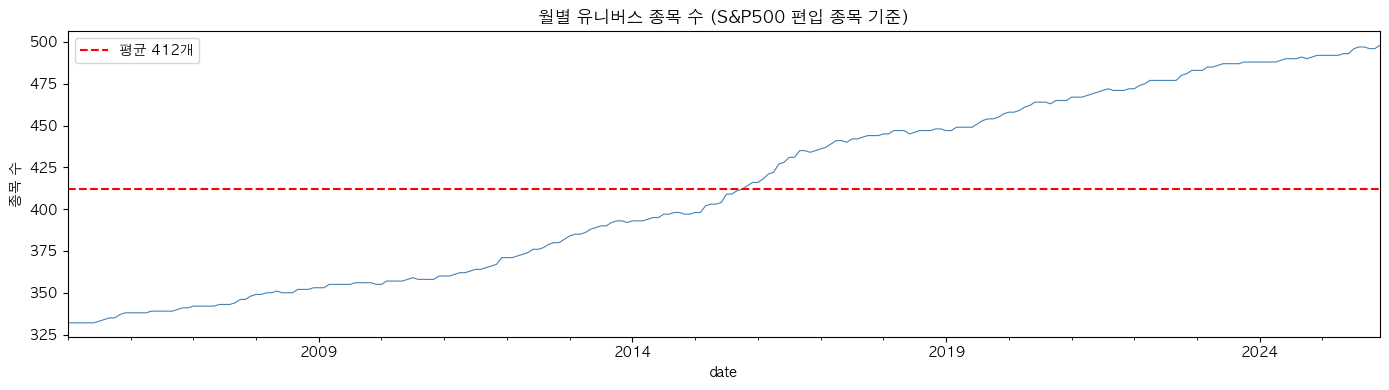

In [112]:
# ── 멤버십 필터링 검증: 실제로 당시 S&P500 편입 종목만 포함되는지 ──
print("=== 포트폴리오 구성 기준 검증: 해당 월 S&P500 편입 종목만 포함 ===\n")

monthly_counts = monthly_df.groupby(level='date').size()
print(f"월별 종목 수 요약:")
print(f"  평균: {monthly_counts.mean():.0f}개  |  최소: {monthly_counts.min()}개  |  최대: {monthly_counts.max()}개\n")

print("[연도별 평균 종목 수]")
yearly = monthly_counts.groupby(monthly_counts.index.year).mean().astype(int)
for yr, cnt in yearly.items():
    print(f"  {yr}: {cnt}개")

print("\n[샘플 월 편입 종목 예시]")
sample_dates = monthly_counts.index[[0, 60, 120, 180, -1]]
for d in sample_dates:
    tickers = monthly_df.loc[d].index.tolist()
    print(f"  {d.date()}: {len(tickers)}종목  → 예시: {tickers[:5]}")

# 시각화
fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(ax=ax, color='steelblue', linewidth=0.8)
ax.axhline(monthly_counts.mean(), color='red', linestyle='--',
           label=f'평균 {monthly_counts.mean():.0f}개')
ax.set_title('월별 유니버스 종목 수 (S&P500 편입 종목 기준)')
ax.set_ylabel('종목 수')
ax.legend()
plt.tight_layout()
plt.show()

=== 기술통계 ===
            ret_1m    beta_252d     vol_252d
count  103844.0000  103280.0000  103280.0000
mean        0.0106       1.0097       0.3097
std         0.0910       0.4095       0.1707
min        -0.8435      -1.6256       0.0905
1%         -0.2273       0.1133       0.1300
5%         -0.1253       0.3792       0.1536
25%        -0.0370       0.7493       0.2072
50%         0.0111       0.9878       0.2662
75%         0.0569       1.2422       0.3597
95%         0.1447       1.7100       0.5953
99%         0.2552       2.1509       0.9657
max         2.4498       3.9243       2.8059

=== 극단값 확인 ===

[ret_1m]
  min=-0.8435  max=2.4498
  1%=-0.2273  99%=0.2552
  1~99% 밖 관측 수: 2078개 (2.0%)

[beta_252d]
  min=-1.6256  max=3.9243
  1%=0.1133  99%=2.1509
  1~99% 밖 관측 수: 2066개 (2.0%)

[vol_252d]
  min=0.0905  max=2.8059
  1%=0.1300  99%=0.9657
  1~99% 밖 관측 수: 2066개 (2.0%)

=== ret_1m 최대값 상위 10개 ===
date        ticker
2009-08-31  AIG       2.449772
2010-02-28  GR        2.333333
2020-0

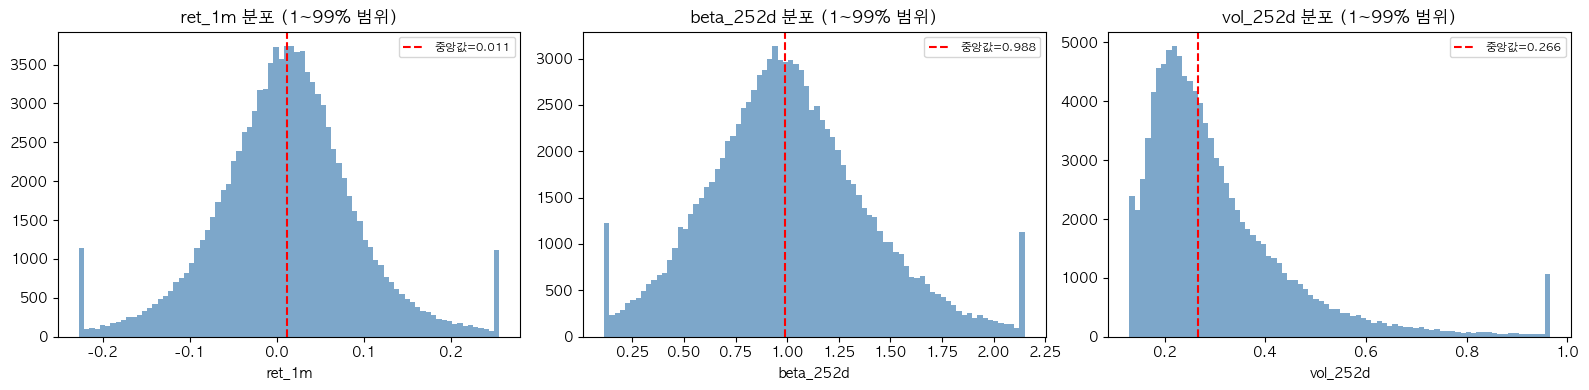

In [113]:
# ── 주요 변수 분포 확인 (포트폴리오 정렬 전) ─────────────────
cols = ['ret_1m', 'beta_252d', 'vol_252d']

print("=== 기술통계 ===")
print(monthly_df[cols].describe(percentiles=[0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).round(4))

print("\n=== 극단값 확인 ===")
for col in cols:
    s = monthly_df[col].dropna()
    print(f"\n[{col}]")
    print(f"  min={s.min():.4f}  max={s.max():.4f}")
    print(f"  1%={s.quantile(0.01):.4f}  99%={s.quantile(0.99):.4f}")
    n_extreme = ((s < s.quantile(0.01)) | (s > s.quantile(0.99))).sum()
    print(f"  1~99% 밖 관측 수: {n_extreme}개 ({n_extreme/len(s):.1%})")

# ── 극단값 원인 확인: ret_1m 상위/하위 10개 ───────────────
print("\n=== ret_1m 최대값 상위 10개 ===")
print(monthly_df['ret_1m'].nlargest(10))

print("\n=== ret_1m 최솟값 하위 10개 ===")
print(monthly_df['ret_1m'].nsmallest(10))

# ── 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, cols):
    s = monthly_df[col].dropna()
    p1, p99 = s.quantile(0.01), s.quantile(0.99)
    ax.hist(s.clip(p1, p99), bins=80, color='steelblue', alpha=0.7)
    ax.set_title(f'{col} 분포 (1~99% 범위)')
    ax.set_xlabel(col)
    ax.axvline(s.median(), color='red', linestyle='--', label=f'중앙값={s.median():.3f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 포트폴리오 정렬 (Portfolio Sort)

## 방법
매월 말 시점에 `beta_252d` / `vol_252d` 기준으로 5분위 정렬:
- **Q1**: 저베타 (저위험) / 저변동
- **Q5**: 고베타 (고위험) / 고변동

각 분위에서 동일가중(Equal-Weight) 포트폴리오를 구성하고 다음 달 수익률(`ret_1m`)을 측정한다.

**Look-ahead bias 방지**: 당월 말 beta로 분류 → 다음 달 수익률 측정 (이미 `ret_1m`에 반영)

In [114]:
def portfolio_sort(df, sort_col, ret_col='ret_1m', n_quantiles=5):
    """
    매월 sort_col 기준으로 n_quantiles 분위 포트폴리오 구성.
    각 분위의 동일가중 수익률 반환.
    """
    results = []
    for date, group in df.groupby(level='date'):
        valid = group[[sort_col, ret_col]].dropna()
        if len(valid) < n_quantiles * 5:  # 분위당 최소 5종목
            continue
        try:
            labels = list(range(1, n_quantiles + 1))
            valid['quintile'] = pd.qcut(valid[sort_col], n_quantiles,
                                        labels=labels, duplicates='drop')
            port_ret = valid.groupby('quintile')[ret_col].mean()
            port_ret.name = date
            results.append(port_ret)
        except Exception as e:
            print(f"  [{date.date()}] 스킵: {e}")
            continue
    return pd.DataFrame(results)


# 베타 기준 포트폴리오
beta_ports = portfolio_sort(monthly_df, 'beta_252d')
# 변동성 기준 포트폴리오
vol_ports  = portfolio_sort(monthly_df, 'vol_252d')

# 무위험수익률 (월별)
rf_monthly = monthly_df['rf_1m'].groupby(level='date').first()

print(f'베타 포트폴리오: {beta_ports.shape[0]}개월 × {beta_ports.shape[1]}분위')
print(f'변동성 포트폴리오: {vol_ports.shape[0]}개월 × {vol_ports.shape[1]}분위')

베타 포트폴리오: 252개월 × 5분위
변동성 포트폴리오: 252개월 × 5분위


In [115]:
# duplicates로 제거되는 분위 수가 있는지 확인
print(beta_ports.isna().sum())
print(vol_ports.isna().sum())

quintile
1    0
2    0
3    0
4    0
5    0
dtype: int64
quintile
1    0
2    0
3    0
4    0
5    0
dtype: int64


In [116]:
# ── 전역 변수 및 함수 정의 ────────────────────────────────────
ANN     = np.sqrt(12)
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
labels  = ['Q1 (저위험)', 'Q2', 'Q3', 'Q4', 'Q5 (고위험)']
spy_monthly = monthly_df['spy_ret'].groupby(level='date').first()

def performance_summary(port_df, rf_series, label='베타'):
    rf_aligned = rf_series.reindex(port_df.index)
    rows = []
    for q in port_df.columns:
        r      = port_df[q].dropna()
        rf     = rf_aligned.reindex(r.index)
        excess = r - rf
        rows.append({
            f'{label} 분위': f'Q{q}',
            '연환산 수익률': f'{r.mean()*12:.2%}',
            '연환산 변동성': f'{r.std()*ANN:.2%}',
            'Sharpe Ratio':  f'{excess.mean()/excess.std()*ANN:.3f}',
            '누적 수익률':    f'{(1+r).prod()-1:.2%}',
        })
    return pd.DataFrame(rows).set_index(f'{label} 분위')

def nw_ttest(series):
    """Newey-West HAC t-test (H0: mean = 0). 자기상관·이분산 보정."""
    s = series.dropna().values
    n = len(s)
    lags = int(4 * (n / 100) ** (2/9))
    res = sm.OLS(s, np.ones(n)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return res.tvalues[0], res.pvalues[0]

print('전역 변수 및 함수 정의 완료')
print(f'  spy_monthly: {spy_monthly.shape[0]}개월 / colors, labels, ANN, performance_summary, nw_ttest')

전역 변수 및 함수 정의 완료
  spy_monthly: 252개월 / colors, labels, ANN, performance_summary, nw_ttest


## 1. 2010~2024 (메인 분석 구간)

=== [2010~2024] 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
베타 분위                                      
Q1     12.25%  11.01%        1.003  469.54%
Q2     13.98%  13.45%        0.949  604.12%
Q3     14.27%  16.39%        0.799  588.86%
Q4     14.98%  19.46%        0.709  604.84%
Q5     14.76%  26.17%        0.519  438.12%

=== [2010~2024] 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
변동성 분위                                      
Q1      14.69%  11.25%        1.199  714.77%
Q2      13.86%  13.66%        0.927  589.02%
Q3      13.82%  16.02%        0.789  549.62%
Q4      13.47%  19.09%        0.644  469.57%
Q5      14.39%  25.53%        0.517  419.66%


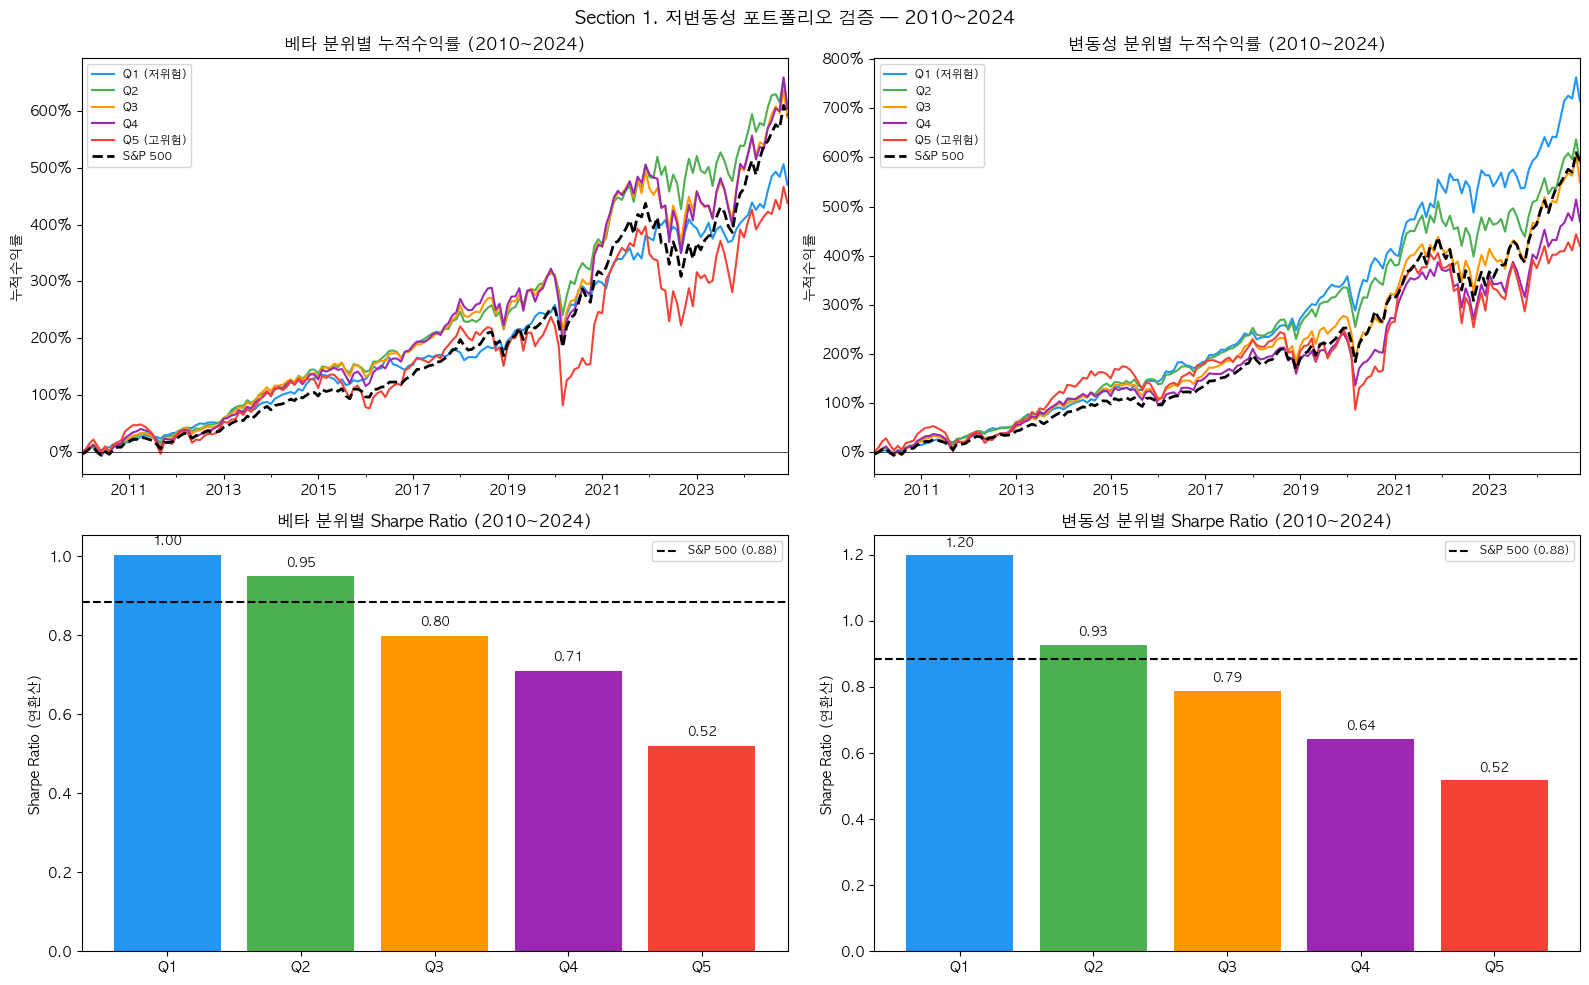


[Q1-Q5 롱숏 스프레드 — 변동성 기준, 2010~2024]
  월평균 스프레드 : 0.0003  (0.30% 연환산)
  스프레드 변동성 : 21.07% (연환산)
  Sharpe          : 0.014
  누적수익 차이(Q1-Q5): 295.11%p
  NW t-통계량     : 0.060  p-value: 0.9521  → 비유의 ✗


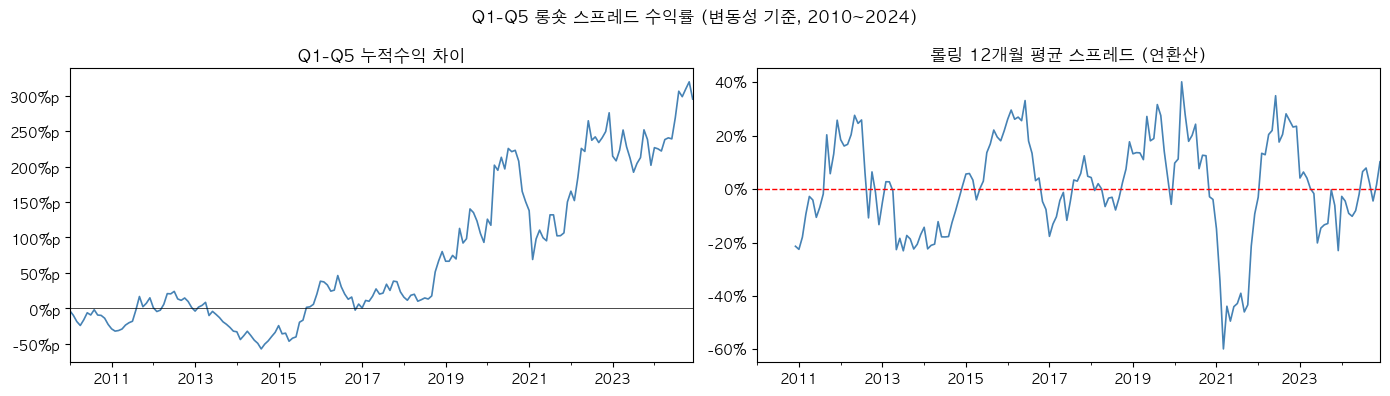

In [117]:
# ── Section 1. 2010~2024 (메인 분석 구간) ───────────────────────
START_BT = '2010-01-01'
END_BT   = '2024-12-31'

df_bt         = monthly_df[
    (monthly_df.index.get_level_values('date') >= START_BT) &
    (monthly_df.index.get_level_values('date') <= END_BT)
]
beta_ports_bt = portfolio_sort(df_bt, 'beta_252d')
vol_ports_bt  = portfolio_sort(df_bt, 'vol_252d')
rf_bt         = rf_monthly[(rf_monthly.index >= START_BT) & (rf_monthly.index <= END_BT)]

print('=== [2010~2024] 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports_bt, rf_bt, '베타'))
print('\n=== [2010~2024] 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports_bt, rf_bt, '변동성'))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Section 1. 저변동성 포트폴리오 검증 — 2010~2024', fontsize=13, fontweight='bold')

rf_b_bt  = rf_bt.reindex(beta_ports_bt.index)
rf_v_bt2 = rf_bt.reindex(vol_ports_bt.index)
spy_bt   = spy_monthly[(spy_monthly.index >= START_BT) & (spy_monthly.index <= END_BT)]
spy_cum_bt = (1 + spy_bt).cumprod() - 1

for ax, ports, title in [
    (axes[0, 0], beta_ports_bt, '베타 분위별 누적수익률 (2010~2024)'),
    (axes[0, 1], vol_ports_bt,  '변동성 분위별 누적수익률 (2010~2024)'),
]:
    for i, q in enumerate(ports.columns):
        (1 + ports[q].dropna()).cumprod().sub(1).plot(ax=ax, label=labels[i], color=colors[i])
    spy_cum_bt.reindex(ports.index).plot(ax=ax, label='S&P 500',
                                          color='black', linestyle='--', linewidth=2)
    ax.set_title(title)
    ax.set_ylabel('누적수익률')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

for ax, ports, rf_a, title in [
    (axes[1, 0], beta_ports_bt, rf_b_bt,  '베타 분위별 Sharpe Ratio (2010~2024)'),
    (axes[1, 1], vol_ports_bt,  rf_v_bt2, '변동성 분위별 Sharpe Ratio (2010~2024)'),
]:
    sr_vals = [(ports[q] - rf_a).mean() / (ports[q] - rf_a).std() * ANN
               for q in ports.columns]
    spy_sr  = (spy_bt.reindex(ports.index) - rf_a).mean() / \
              (spy_bt.reindex(ports.index) - rf_a).std() * ANN
    bars = ax.bar([f'Q{q}' for q in ports.columns], sr_vals, color=colors)
    ax.axhline(spy_sr, color='black', linestyle='--', linewidth=1.5,
               label=f'S&P 500 ({spy_sr:.2f})')
    ax.set_title(title)
    ax.set_ylabel('Sharpe Ratio (연환산)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, sr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort_2010.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Q1-Q5 롱숏 스프레드 수익률 ───────────────────────────────
spread_bt  = vol_ports_bt[1] - vol_ports_bt[5]
ann_spread = spread_bt.mean() * 12
t_stat, p_val = nw_ttest(spread_bt)

_diff_bt = (1+vol_ports_bt[1].dropna()).prod()-1 - ((1+vol_ports_bt[5].dropna()).prod()-1)

print('\n' + '=' * 55)
print('[Q1-Q5 롱숏 스프레드 — 변동성 기준, 2010~2024]')
print('=' * 55)
print(f'  월평균 스프레드 : {spread_bt.mean():.4f}  ({ann_spread:.2%} 연환산)')
print(f'  스프레드 변동성 : {spread_bt.std()*ANN:.2%} (연환산)')
print(f'  Sharpe          : {spread_bt.mean()/spread_bt.std()*ANN:.3f}')
print(f'  누적수익 차이(Q1-Q5): {_diff_bt*100:.2f}%p')
print(f'  NW t-통계량     : {t_stat:.3f}  p-value: {p_val:.4f}  '
      f'→ {"유의 (p<0.05) ✓" if p_val < 0.05 else "비유의 ✗"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Q1-Q5 롱숏 스프레드 수익률 (변동성 기준, 2010~2024)', fontsize=12)
((1 + vol_ports_bt[1]).cumprod() - 1 - ((1 + vol_ports_bt[5]).cumprod() - 1)).plot(ax=axes[0], color='steelblue', linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Q1-Q5 누적수익 차이')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:.0f}%p'))
(spread_bt.rolling(12).mean() * 12).plot(ax=axes[1], color='steelblue', linewidth=1.2)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('롤링 12개월 평균 스프레드 (연환산)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

### 1-2. 30%/30% 분류 기준 성과

=== [30%/30% 분류 기준 — 2010~2024] ===
          그룹 연환산 수익률 연환산 변동성 Sharpe  누적 수익률
저변동 (하위 30%)  14.42%  11.64%  1.136 677.87%
고변동 (상위 30%)  14.30%  23.56%  0.557 455.19%

[스프레드 (저변동 - 고변동)]
  월평균        : 0.0001  (0.12% 연환산)
  스프레드 변동성: 17.42% (연환산)
  Sharpe        : 0.007
  누적수익 차이(저변동-고변동): 222.68%p
  NW t-통계량   : 0.030  p-value: 0.9761  → 비유의 ✗


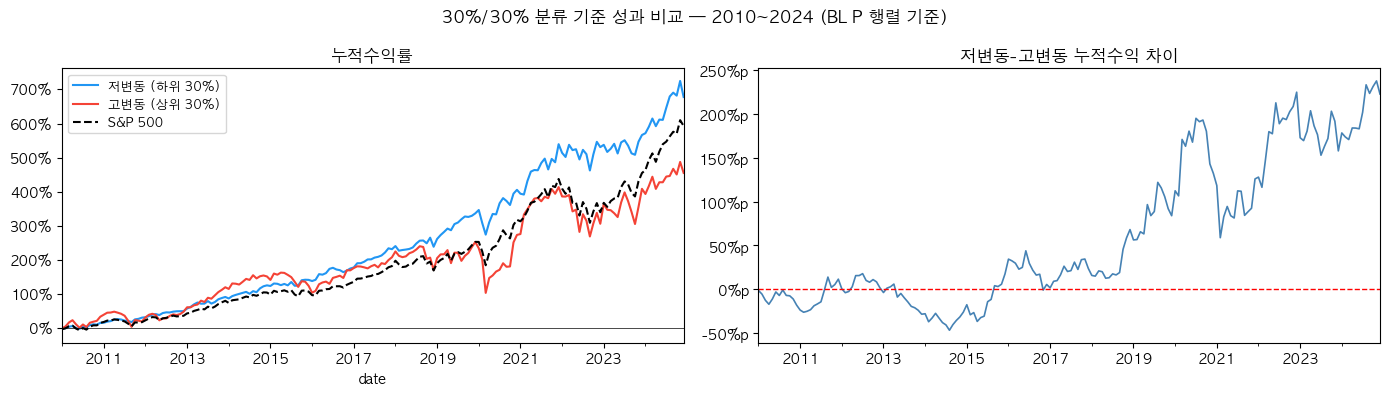

In [118]:
# ── Section 1-2. 30%/30% 분류 기준 성과 ──
LOW_PCTILE  = 0.30
HIGH_PCTILE = 0.70

def portfolio_30(df, sort_col='vol_252d', ret_col='ret_1m'):
    low_rets, high_rets, dates = [], [], []
    for date, group in df.groupby(level='date'):
        valid = group[[sort_col, ret_col]].dropna()
        if len(valid) < 20:
            continue
        q_low  = valid[sort_col].quantile(LOW_PCTILE)
        q_high = valid[sort_col].quantile(HIGH_PCTILE)
        low_rets.append(valid[valid[sort_col] <= q_low][ret_col].mean())
        high_rets.append(valid[valid[sort_col] >= q_high][ret_col].mean())
        dates.append(date)
    return pd.Series(low_rets, index=pd.DatetimeIndex(dates)), \
           pd.Series(high_rets, index=pd.DatetimeIndex(dates))

low_30, high_30 = portfolio_30(df_bt)
rf_30 = rf_bt.reindex(low_30.index)

def _stats(r, rf, label):
    exc = r - rf
    return {'그룹': label, '연환산 수익률': f'{r.mean()*12:.2%}',
            '연환산 변동성': f'{r.std()*ANN:.2%}',
            'Sharpe': f'{exc.mean()/exc.std()*ANN:.3f}',
            '누적 수익률': f'{(1+r).prod()-1:.2%}'}

print('=== [30%/30% 분류 기준 — 2010~2024] ===')
print(pd.DataFrame([_stats(low_30, rf_30, '저변동 (하위 30%)'),
                    _stats(high_30, rf_30, '고변동 (상위 30%)')]).to_string(index=False))

spread_30  = low_30 - high_30
t30, p30   = nw_ttest(spread_30)

_diff_30 = (1+low_30).prod()-1 - ((1+high_30).prod()-1)

print(f'\n[스프레드 (저변동 - 고변동)]')
print(f'  월평균        : {spread_30.mean():.4f}  ({spread_30.mean()*12:.2%} 연환산)')
print(f'  스프레드 변동성: {spread_30.std()*ANN:.2%} (연환산)')
print(f'  Sharpe        : {spread_30.mean()/spread_30.std()*ANN:.3f}')
print(f'  누적수익 차이(저변동-고변동): {_diff_30*100:.2f}%p')
print(f'  NW t-통계량   : {t30:.3f}  p-value: {p30:.4f}  → {"유의 (p<0.05) ✓" if p30 < 0.05 else "비유의 ✗"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('30%/30% 분류 기준 성과 비교 — 2010~2024 (BL P 행렬 기준)', fontsize=12)
ax = axes[0]
(1+low_30).cumprod().sub(1).plot(ax=ax, label='저변동 (하위 30%)', color='#2196F3', linewidth=1.5)
(1+high_30).cumprod().sub(1).plot(ax=ax, label='고변동 (상위 30%)', color='#F44336', linewidth=1.5)
spy_cum_bt.plot(ax=ax, label='S&P 500', color='black', linestyle='--', linewidth=1.5)
ax.set_title('누적수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(fontsize=9)
((1 + low_30).cumprod() - 1 - ((1 + high_30).cumprod() - 1)).plot(ax=axes[1], color='steelblue', linewidth=1.2)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('저변동-고변동 누적수익 차이')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:.0f}%p'))
plt.tight_layout()
plt.show()

## 2. 2016~2024 (강세장 제거)

=== [2016~2024] 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
베타 분위                                      
Q1     11.04%  12.26%        0.742  151.80%
Q2     12.71%  14.50%        0.742  184.24%
Q3     13.05%  17.54%        0.634  180.51%
Q4     14.51%  20.69%        0.608  202.54%
Q5     15.00%  28.38%        0.461  164.71%

=== [2016~2024] 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio   누적 수익률
변동성 분위                                      
Q1      14.19%  12.42%        0.985  232.65%
Q2      12.49%  14.76%        0.716  177.96%
Q3      13.36%  17.07%        0.670  190.48%
Q4      12.86%  20.05%        0.546  164.40%
Q5      13.39%  27.88%        0.411  131.25%


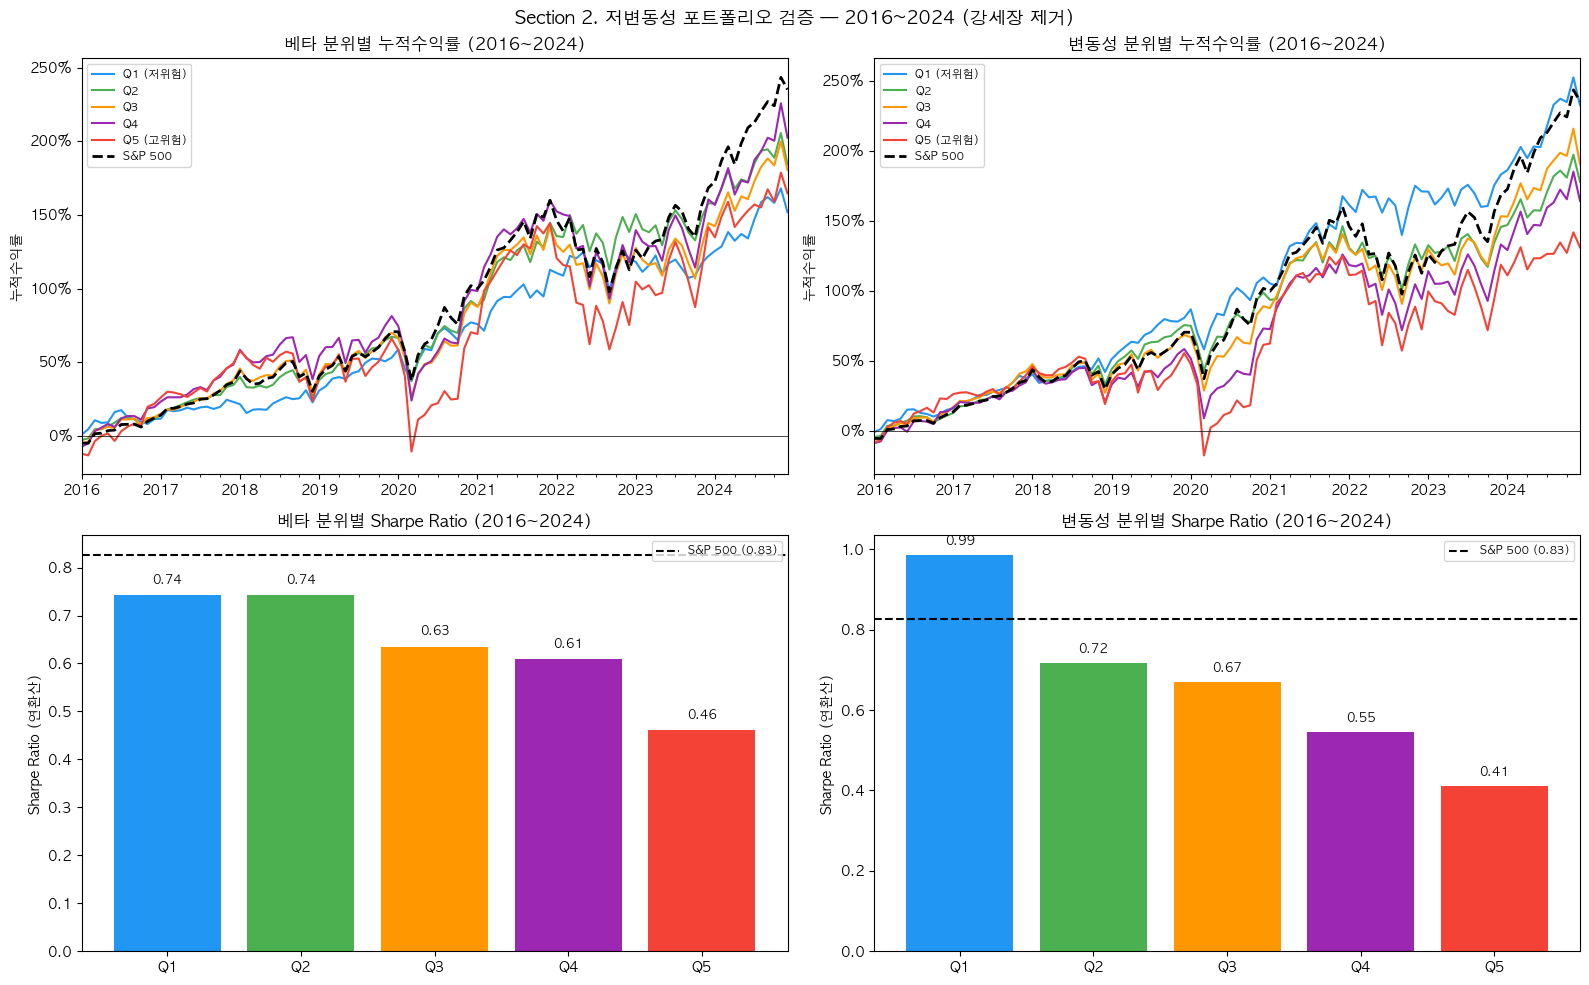

In [119]:
# ── Section 2. 2016~2024 (강세장 제거) ───────────────────────────
# 2010~2015: GFC 이후 QE 주도 강세장 — 고변동성 종목 강한 반등 구간
# 2015년 이전 제외하면 저변동 우위가 더 뚜렷하게 나타나는지 확인
START_R = '2016-01-01'
END_R   = '2024-12-31'

df_r         = monthly_df[
    (monthly_df.index.get_level_values('date') >= START_R) &
    (monthly_df.index.get_level_values('date') <= END_R)
]
beta_ports_r = portfolio_sort(df_r, 'beta_252d')
vol_ports_r  = portfolio_sort(df_r, 'vol_252d')
rf_r         = rf_monthly[(rf_monthly.index >= START_R) & (rf_monthly.index <= END_R)]

print('=== [2016~2024] 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports_r, rf_r, '베타'))
print('\n=== [2016~2024] 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports_r, rf_r, '변동성'))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Section 2. 저변동성 포트폴리오 검증 — 2016~2024 (강세장 제거)', fontsize=13, fontweight='bold')

rf_b_r  = rf_r.reindex(beta_ports_r.index)
rf_v_r  = rf_r.reindex(vol_ports_r.index)
spy_r   = spy_monthly[(spy_monthly.index >= START_R) & (spy_monthly.index <= END_R)]
spy_cum_r = (1 + spy_r).cumprod() - 1

for ax, ports, title in [
    (axes[0, 0], beta_ports_r, '베타 분위별 누적수익률 (2016~2024)'),
    (axes[0, 1], vol_ports_r,  '변동성 분위별 누적수익률 (2016~2024)'),
]:
    for i, q in enumerate(ports.columns):
        cum = (1 + ports[q].dropna()).cumprod() - 1
        cum.plot(ax=ax, label=labels[i], color=colors[i])
    spy_cum_r.reindex(ports.index).plot(ax=ax, label='S&P 500',
                                         color='black', linestyle='--', linewidth=2)
    ax.set_title(title)
    ax.set_ylabel('누적수익률')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

for ax, ports, rf_a, title in [
    (axes[1, 0], beta_ports_r, rf_b_r, '베타 분위별 Sharpe Ratio (2016~2024)'),
    (axes[1, 1], vol_ports_r,  rf_v_r, '변동성 분위별 Sharpe Ratio (2016~2024)'),
]:
    sr_vals = [(ports[q] - rf_a).mean() / (ports[q] - rf_a).std() * ANN
               for q in ports.columns]
    spy_sr  = (spy_r.reindex(ports.index) - rf_a).mean() / \
              (spy_r.reindex(ports.index) - rf_a).std() * ANN
    bars = ax.bar([f'Q{q}' for q in ports.columns], sr_vals, color=colors)
    ax.axhline(spy_sr, color='black', linestyle='--', linewidth=1.5,
               label=f'S&P 500 ({spy_sr:.2f})')
    ax.set_title(title)
    ax.set_ylabel('Sharpe Ratio (연환산)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, sr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort_2016.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 2005~2024 (금융위기 포함 전체 기간)

In [120]:
# ── Section 3. 2005~2024 (금융위기 포함 전체 기간) ───────────────
print('=== [2005~2024] 베타 기준 포트폴리오 성과 ===')
print(performance_summary(beta_ports, rf_monthly, '베타'))
print('\n=== [2005~2024] 변동성 기준 포트폴리오 성과 ===')
print(performance_summary(vol_ports, rf_monthly, '변동성'))

=== [2005~2024] 베타 기준 포트폴리오 성과 ===
      연환산 수익률 연환산 변동성 Sharpe Ratio    누적 수익률
베타 분위                                       
Q1     10.33%  11.18%        0.773   661.18%
Q2     11.76%  13.50%        0.745   864.10%
Q3     12.53%  17.22%        0.630   903.65%
Q4     13.78%  20.55%        0.589  1046.29%
Q5     14.62%  27.24%        0.476   869.51%

=== [2005~2024] 변동성 기준 포트폴리오 성과 ===
       연환산 수익률 연환산 변동성 Sharpe Ratio    누적 수익률
변동성 분위                                       
Q1      11.97%  11.16%        0.920   971.94%
Q2      11.31%  13.84%        0.696   770.21%
Q3      12.28%  16.84%        0.630   865.54%
Q4      12.17%  19.83%        0.529   743.35%
Q5      15.27%  27.15%        0.501  1018.24%


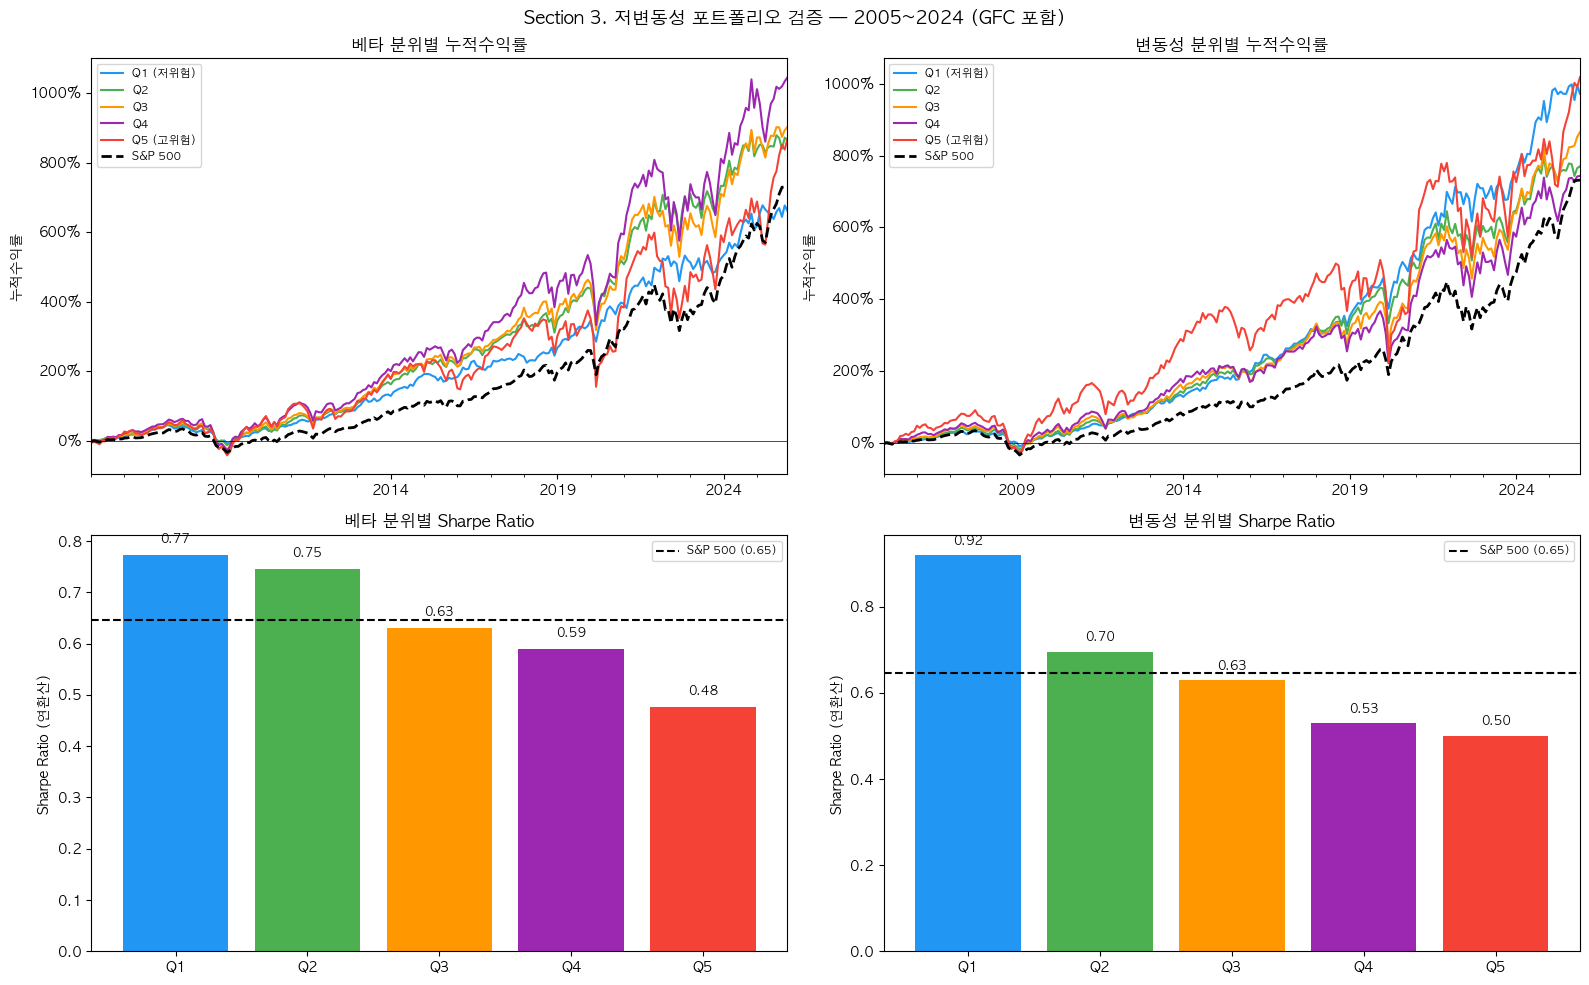

In [121]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Section 3. 저변동성 포트폴리오 검증 — 2005~2024 (GFC 포함)', fontsize=13, fontweight='bold')

spy_cum     = (1 + spy_monthly).cumprod() - 1
rf_a_beta   = rf_monthly.reindex(beta_ports.index)
rf_a_vol    = rf_monthly.reindex(vol_ports.index)

for ax, ports, rf_a, title_cum in [
    (axes[0, 0], beta_ports, rf_a_beta, '베타 분위별 누적수익률'),
    (axes[0, 1], vol_ports,  rf_a_vol,  '변동성 분위별 누적수익률'),
]:
    for i, q in enumerate(ports.columns):
        (1 + ports[q].dropna()).cumprod().sub(1).plot(ax=ax, label=labels[i], color=colors[i])
    spy_cum.reindex(ports.index).plot(ax=ax, label='S&P 500', color='black', linestyle='--', linewidth=2)
    ax.set_title(title_cum)
    ax.set_ylabel('누적수익률')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)

for ax, ports, rf_a, title_sr in [
    (axes[1, 0], beta_ports, rf_a_beta, '베타 분위별 Sharpe Ratio'),
    (axes[1, 1], vol_ports,  rf_a_vol,  '변동성 분위별 Sharpe Ratio'),
]:
    sr_vals = [(ports[q] - rf_a).mean() / (ports[q] - rf_a).std() * ANN for q in ports.columns]
    spy_sr  = (spy_monthly.reindex(ports.index) - rf_a).mean() / \
              (spy_monthly.reindex(ports.index) - rf_a).std() * ANN
    bars = ax.bar([f'Q{q}' for q in ports.columns], sr_vals, color=colors)
    ax.axhline(spy_sr, color='black', linestyle='--', linewidth=1.5, label=f'S&P 500 ({spy_sr:.2f})')
    ax.set_title(title_sr)
    ax.set_ylabel('Sharpe Ratio (연환산)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, sr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_sort.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 변동성-시가총액 관계 (2010~2024 기준)

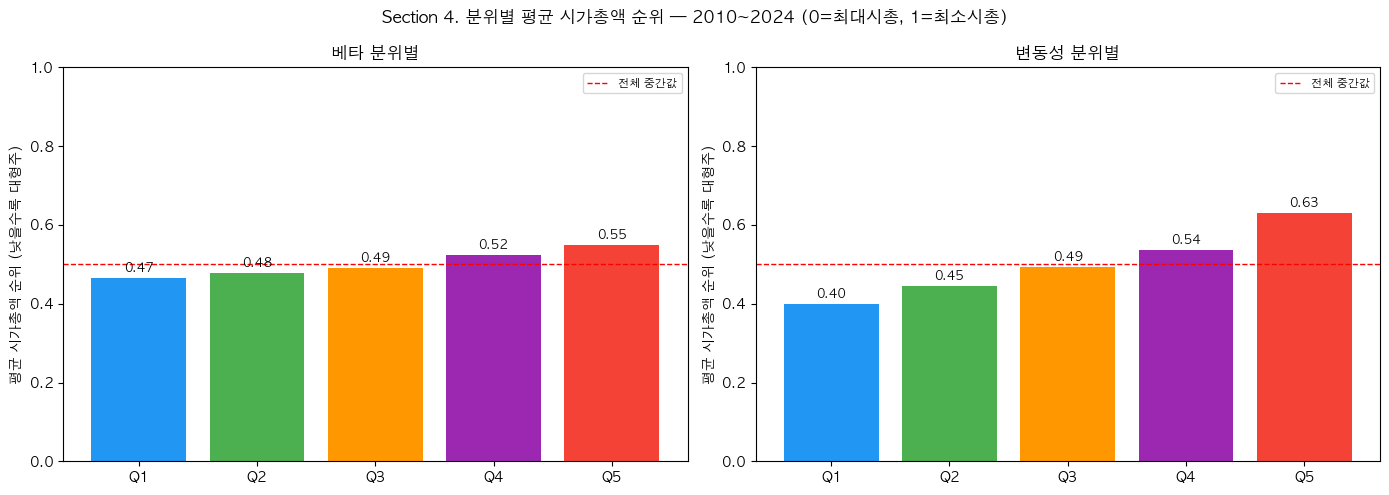

[변동성-시가총액 Spearman 상관관계 검정 — 2010~2024]
  월평균 ρ      : -0.281
  ρ 범위        : -0.425 ~ -0.185
  NW t-통계량   : -34.063  p-value: 2.58e-254
  해석          : 저변동성 ↔ 대형주 유의한 음의 상관 ✓
  → BL prior(시가총액 가중)와 저변동성 분류가 겹치는 경향 있음


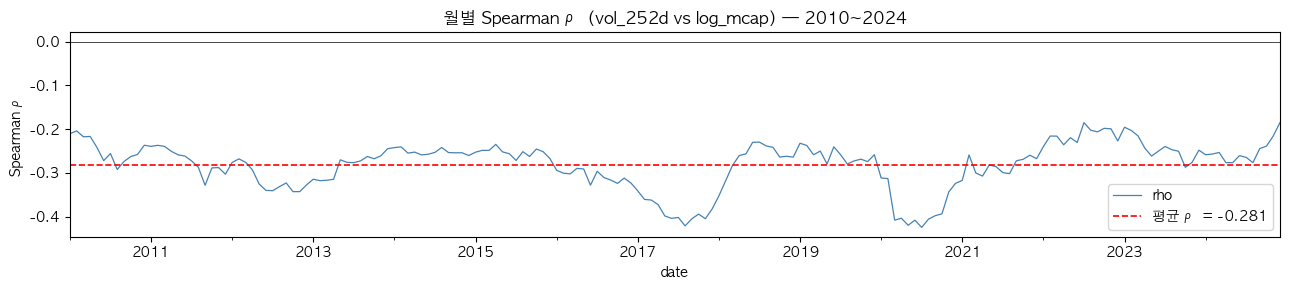

In [122]:
# ── Section 4. 변동성-시가총액 관계 (2010~2024 기준) ────────────
# BL 모델에서 시가총액 가중 prior를 사용하므로
# 저변동성과 대형주가 겹치는지 확인 — 메인 분석 구간(2010~2024) 기준

def quintile_mcap_rank(df, sort_col):
    rows = []
    for date, group in df.groupby(level='date'):
        valid = group[[sort_col, 'log_mcap']].dropna()
        if len(valid) < 25:
            continue
        try:
            valid = valid.copy()
            valid['quintile'] = pd.qcut(valid[sort_col], 5,
                                        labels=[1, 2, 3, 4, 5], duplicates='drop')
            valid['mcap_rank'] = valid['log_mcap'].rank(ascending=False, pct=True)
            for q, grp in valid.groupby('quintile'):
                rows.append({'date': date, 'quintile': int(q),
                             'avg_rank': grp['mcap_rank'].mean()})
        except Exception:
            continue
    return pd.DataFrame(rows)

rank_beta = quintile_mcap_rank(df_bt, 'beta_252d')
rank_vol  = quintile_mcap_rank(df_bt, 'vol_252d')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 4. 분위별 평균 시가총액 순위 — 2010~2024 (0=최대시총, 1=최소시총)', fontsize=12)

for ax, rank_df, title in [
    (axes[0], rank_beta, '베타 분위별'),
    (axes[1], rank_vol,  '변동성 분위별'),
]:
    avg = rank_df.groupby('quintile')['avg_rank'].mean()
    bars = ax.bar([f'Q{q}' for q in avg.index], avg.values, color=colors)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel('평균 시가총액 순위 (낮을수록 대형주)')
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='전체 중간값')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'quintile_mcap_rank.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Spearman 상관관계 검정: 변동성 ↔ 시가총액 (2010~2024) ──────
monthly_corr = []
for date, group in df_bt.groupby(level='date'):
    valid = group[['vol_252d', 'log_mcap']].dropna()
    if len(valid) < 20:
        continue
    rho, _ = stats.spearmanr(valid['vol_252d'], valid['log_mcap'])
    monthly_corr.append({'date': date, 'rho': rho})

corr_df    = pd.DataFrame(monthly_corr).set_index('date')
mean_rho   = corr_df['rho'].mean()
t_stat, p_val = nw_ttest(corr_df['rho'])

print('=' * 55)
print('[변동성-시가총액 Spearman 상관관계 검정 — 2010~2024]')
print('=' * 55)
print(f'  월평균 ρ      : {mean_rho:.3f}')
print(f'  ρ 범위        : {corr_df["rho"].min():.3f} ~ {corr_df["rho"].max():.3f}')
print(f'  NW t-통계량   : {t_stat:.3f}  p-value: {p_val:.2e}')
print(f'  해석          : 저변동성 ↔ 대형주 {"유의한 음의 상관 ✓" if mean_rho < 0 and p_val < 0.05 else "유의하지 않음"}')
print(f'  → BL prior(시가총액 가중)와 저변동성 분류가 {"겹치는 경향 있음" if mean_rho < -0.2 else "크게 다름"}')

fig, ax = plt.subplots(figsize=(13, 3))
corr_df['rho'].plot(ax=ax, color='steelblue', linewidth=0.9)
ax.axhline(mean_rho, color='red', linestyle='--', linewidth=1.2,
           label=f'평균 ρ = {mean_rho:.3f}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('월별 Spearman ρ (vol_252d vs log_mcap) — 2010~2024')
ax.set_ylabel('Spearman ρ')
ax.legend()
plt.tight_layout()
plt.show()

# 결과 요약

아래 셀을 실행하면 주요 검증 결과를 한눈에 정리해줍니다.

In [123]:
print('=' * 55)
print('저위험 이상현상 검증 결과 요약')
print('=' * 55)

rf_b = rf_monthly.reindex(beta_ports_bt.index)
rf_v = rf_monthly.reindex(vol_ports_bt.index)

sr_beta = {q: (beta_ports_bt[q] - rf_b).mean() / (beta_ports_bt[q] - rf_b).std() * ANN
           for q in beta_ports_bt.columns}
sr_vol  = {q: (vol_ports_bt[q]  - rf_v).mean()  / (vol_ports_bt[q]  - rf_v).std()  * ANN
           for q in vol_ports_bt.columns}

print(f'\n[베타 기준]  Q1 SR: {sr_beta[1]:.3f}  →  Q5 SR: {sr_beta[5]:.3f}  '
      f'스프레드: {sr_beta[1]-sr_beta[5]:.3f}  '
      f'→ {"저위험 이상현상 확인 ✓" if sr_beta[1] > sr_beta[5] else "미확인 ✗"}')

print(f'\n[변동성 기준]  Q1 SR: {sr_vol[1]:.3f}  →  Q5 SR: {sr_vol[5]:.3f}  '
      f'스프레드: {sr_vol[1]-sr_vol[5]:.3f}  '
      f'→ {"저위험 이상현상 확인 ✓" if sr_vol[1] > sr_vol[5] else "미확인 ✗"}')

print('\n' + '=' * 55)

저위험 이상현상 검증 결과 요약

[베타 기준]  Q1 SR: 1.003  →  Q5 SR: 0.519  스프레드: 0.484  → 저위험 이상현상 확인 ✓

[변동성 기준]  Q1 SR: 1.199  →  Q5 SR: 0.517  스프레드: 0.681  → 저위험 이상현상 확인 ✓



CAPM 알파 검정 — 변동성 분위 (2010~2024, Newey-West)
      α (월) α (연환산)      β   NW t p-value 유의
분위                                          
Q1   0.0046   5.55%  0.620   3.25  0.0011  ✓
Q2   0.0011   1.27%  0.889   1.06  0.2879  ✗
Q3  -0.0007  -0.88%  1.052  -0.69  0.4907  ✗
Q4  -0.0029  -3.53%  1.231  -1.93  0.0537  ✗
Q5  -0.0056  -6.74%  1.552  -1.90  0.0574  ✗

해석:
  α > 0 & 유의 → 시장 위험 통제 후에도 초과수익 → 저변동 포트폴리오 자체의 우위
  α < 0 & 유의 → 위험 대비 보상 부족 → CAPM 예측 하회


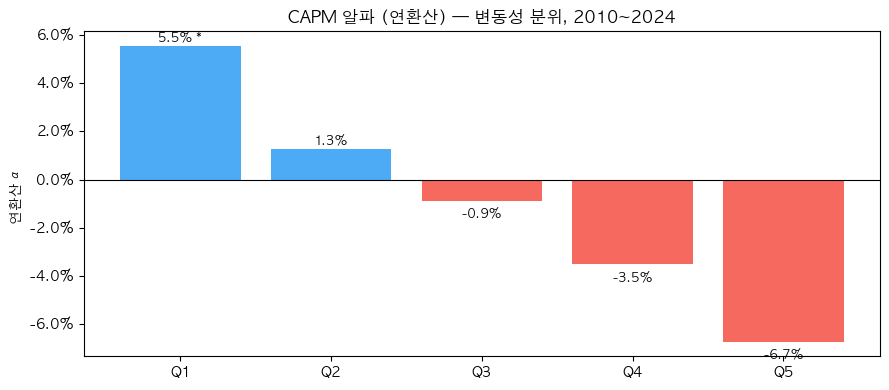

In [124]:
# ── CAPM 알파 검정 (2010~2024) ─────────────────────────────────
# 변동성 분위별로 시장 위험(β)을 통제한 후에도 초과수익(α)이 남는지 검정
# α > 0 이면: 저변동 포트폴리오를 들고 있는 것만으로 시장 이상의 수익
# H0: α = 0  vs  H1: α ≠ 0  (Newey-West HAC)

mkt_ex = (spy_bt - rf_bt.reindex(spy_bt.index)).dropna()

rows, alphas, pvals = [], [], []
for q in vol_ports_bt.columns:
    r      = vol_ports_bt[q].dropna()
    excess = (r - rf_bt.reindex(r.index)).dropna()

    idx  = excess.index.intersection(mkt_ex.index)
    y, X = excess.reindex(idx), sm.add_constant(mkt_ex.reindex(idx))

    n    = len(y)
    lags = int(4 * (n / 100) ** (2/9))
    res  = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})

    a, b     = res.params.iloc[0], res.params.iloc[1]
    t_a, p_a = res.tvalues.iloc[0], res.pvalues.iloc[0]

    rows.append({
        '분위':      f'Q{q}',
        'α (월)':    f'{a:.4f}',
        'α (연환산)': f'{a*12:.2%}',
        'β':         f'{b:.3f}',
        'NW t':      f'{t_a:.2f}',
        'p-value':   f'{p_a:.4f}',
        '유의':      '✓' if p_a < 0.05 else '✗',
    })
    alphas.append(a * 12)
    pvals.append(p_a)

print('=' * 65)
print('CAPM 알파 검정 — 변동성 분위 (2010~2024, Newey-West)')
print('=' * 65)
print(pd.DataFrame(rows).set_index('분위').to_string())
print()
print('해석:')
print('  α > 0 & 유의 → 시장 위험 통제 후에도 초과수익 → 저변동 포트폴리오 자체의 우위')
print('  α < 0 & 유의 → 위험 대비 보상 부족 → CAPM 예측 하회')

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#2196F3' if a > 0 else '#F44336' for a in alphas]
bars = ax.bar([f'Q{q}' for q in vol_ports_bt.columns], alphas, color=bar_colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('CAPM 알파 (연환산) — 변동성 분위, 2010~2024', fontsize=12)
ax.set_ylabel('연환산 α')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, val, p in zip(bars, alphas, pvals):
    sig = ' *' if p < 0.05 else ''
    ypos = bar.get_height() + 0.001 if val >= 0 else bar.get_height() - 0.003
    va   = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.1%}{sig}', ha='center', va=va, fontsize=9)
plt.tight_layout()
plt.show()

---

## 종합 해석

### 저위험 이상현상 확인 여부

| 지표 | Q1 (저변동) | Q5 (고변동) |
|---|---|---|
| Sharpe (2010~2024) | **1.199** | 0.517 |
| CAPM α (연환산) | **+5.55%** *(p=0.001)* | -6.74% |
| β | **0.620** | 1.552 |
| 누적수익 (2010~2024) | 677.87% | 455.19% |

Q1은 시장 위험(β=0.62)이 낮음에도 CAPM 예측을 크게 상회하는 알파(+5.55%/년, p=0.001)가 통계적으로 유의하게 존재한다. CAPM 이론대로라면 저β → 저수익이어야 하지만 반대 결과가 나타나며, 이것이 **저위험 이상현상**이다.

---

### 한계

1. **스프레드 t-test 비유의**: 월별 수익률 차이의 절대값이 작고 노이즈가 커서 통계적 유의성 미확보 — Sharpe·CAPM 알파로 보완
2. **후향적 변동성**: `vol_252d`는 과거 1년 실현 변동성 → 미래 분류에 오류 가능성 존재
3. **생존편향**: S&P500 편출 종목(주로 고변동) 최종 수익 미반영 → Q5 성과 과소평가 가능